In [107]:
import pandas as pd

df = pd.read_csv("../dataset/transactions.csv")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Rows: 60000
Columns: 10

Column names:
['transaction_id', 'date', 'department', 'category', 'vendor', 'region', 'transaction_type', 'amount', 'payment_method', 'description']

First 5 rows:


,transaction_id,date,department,category,vendor,region,transaction_type,amount,payment_method,description
0,TXN100000,2025-01-01,Sales,Commissions,SalesPartners,West,Expense,22477.74,Credit Card,Commissions transaction for Sales
1,TXN100001,2025-01-01,Customer Support,Service Revenue,Customer_E,West,Revenue,17920.46,Bank Transfer,Service Revenue transaction for Customer Support
2,TXN100002,2025-01-01,Finance,Subscription,Customer_C,West,Revenue,14017.17,Debit Card,Subscription transaction for Finance
3,TXN100003,2025-01-01,Sales,Commissions,SalesPartners,South,Expense,6900.02,Bank Transfer,Commissions transaction for Sales
4,TXN100004,2025-01-01,IT,Cloud Services,DataCloud,South,Expense,10066.59,Debit Card,Cloud Services transaction for IT


In [108]:
# Check missing values in each column

missing_values = df.isnull().sum()

print("Missing values:")
print(missing_values)

Missing values:
transaction_id      0
date                0
department          0
category            0
vendor              0
region              0
transaction_type    0
amount              0
payment_method      0
description         0
dtype: int64


In [109]:
# Check for duplicate transaction IDs

duplicate_count = df["transaction_id"].duplicated().sum()

print("Duplicate transaction IDs:", duplicate_count)

Duplicate transaction IDs: 0


In [110]:
print("Data types:")
print(df.dtypes)

Data types:
transaction_id       object
date                 object
department           object
category             object
vendor               object
region               object
transaction_type     object
amount              float64
payment_method       object
description          object
dtype: object


In [111]:
df["date"]=pd.to_datetime(df["date"])
print("Date data type",df["date"].dtype)

Date data type datetime64[ns]


In [112]:
print(df.columns.tolist())

['transaction_id', 'date', 'department', 'category', 'vendor', 'region', 'transaction_type', 'amount', 'payment_method', 'description']


In [113]:
print(df.shape)
print(df.columns.tolist())

(60000, 10)
['transaction_id', 'date', 'department', 'category', 'vendor', 'region', 'transaction_type', 'amount', 'payment_method', 'description']


In [114]:
# Count of Revenue vs Expense transactions
print("Transaction Type Distribution:")
print(df["transaction_type"].value_counts())

Transaction Type Distribution:
transaction_type
Expense    37190
Revenue    22810
Name: count, dtype: int64


In [115]:
# Number of transactions by department
print("Transactions by Department:")
print(df["department"].value_counts())

Transactions by Department:
department
Operations          11425
Marketing           10239
Sales                9623
Customer Support     9043
IT                   8389
Finance              5838
HR                   5443
Name: count, dtype: int64


In [116]:
# Number of transactions by category
print("Transactions by Category:")
print(df["category"].value_counts())

Transactions by Category:
category
Software                 7525
Product Sales            5807
Subscription             5723
Service Revenue          5652
Transaction Fees         5628
Training                 2227
Logistics                1815
Maintenance              1787
Supplies                 1766
Utilities                1749
Content                  1595
Events                   1574
Advertising              1570
Commissions              1503
Client Entertainment     1500
Travel                   1478
Support Tools            1443
Outsourcing              1412
Hardware                 1329
Cybersecurity            1310
Cloud Services           1292
Audit                     926
Bank Charges              923
Professional Services     834
Benefits                  819
Recruitment               813
Name: count, dtype: int64


In [117]:
# Financial summary by transaction type
print("Amount Summary by Transaction Type:")

display(
    df.groupby("transaction_type")["amount"]
      .agg(["count", "sum", "mean", "min", "max"]))

Amount Summary by Transaction Type:


,count,sum,mean,min,max
transaction_type,,,,,
Expense,37190,4.330657e+08,11644.680102,465.04,138316.89
Revenue,22810,5.118620e+08,22440.244183,1206.70,272498.85


In [118]:
# Load monthly budget dataset

budget_df = pd.read_csv("../dataset/monthly_budgets.csv")

print("Budget dataset shape:", budget_df.shape)

print("\nBudget columns:")
print(budget_df.columns.tolist())

print("\nFirst 5 rows:")
display(budget_df.head())

print("Budget data types:")
print(budget_df.dtypes)

print("Missing values in budget dataset:")
print(budget_df.isnull().sum())

print("Duplicate budget records:", budget_df.duplicated().sum())

Budget dataset shape: (504, 5)

Budget columns:
['month', 'department', 'category', 'actual_expense', 'budget']

First 5 rows:


,month,department,category,actual_expense,budget
0,2025-01,Customer Support,Outsourcing,906916.46,913791.70
1,2025-01,Customer Support,Software,724787.64,737863.28
2,2025-01,Customer Support,Support Tools,658831.34,640835.18
3,2025-01,Customer Support,Training,483785.12,477200.44
4,2025-01,Finance,Audit,276168.70,270906.81


Budget data types:
month              object
department         object
category           object
actual_expense    float64
budget            float64
dtype: object
Missing values in budget dataset:
month             0
department        0
category          0
actual_expense    0
budget            0
dtype: int64
Duplicate budget records: 0


In [119]:
# Compare actual expense with budget

budget_df["variance"] = budget_df["actual_expense"] - budget_df["budget"]

budget_df["variance_percentage"] = (
    budget_df["variance"] / budget_df["budget"]
) * 100

display(budget_df.head())

,month,department,category,actual_expense,budget,variance,variance_percentage
0,2025-01,Customer Support,Outsourcing,906916.46,913791.70,-6875.24,-0.752386
1,2025-01,Customer Support,Software,724787.64,737863.28,-13075.64,-1.772095
2,2025-01,Customer Support,Support Tools,658831.34,640835.18,17996.16,2.808235
3,2025-01,Customer Support,Training,483785.12,477200.44,6584.68,1.379856
4,2025-01,Finance,Audit,276168.70,270906.81,5261.89,1.942325


In [120]:
# Identify over-budget categories

over_budget = budget_df[budget_df["variance"] > 0]

print("Number of over-budget records:", len(over_budget))

display(
    over_budget.sort_values(
        by="variance",
        ascending=False
    ).head(10)
)

Number of over-budget records: 343


,month,department,category,actual_expense,budget,variance,variance_percentage
156,2025-06,Marketing,Advertising,2011660.66,1857796.83,153863.83,8.282059
415,2026-03,Operations,Utilities,1901670.98,1763682.84,137988.14,7.823864
137,2025-05,Sales,Commissions,1275953.18,1150475.28,125477.90,10.906614
165,2025-06,Sales,Commissions,1393504.07,1269786.90,123717.17,9.743144
16,2025-01,Marketing,Advertising,1429909.48,1308522.04,121387.44,9.276683
440,2026-04,Operations,Logistics,2128027.72,2007389.75,120637.97,6.009693
98,2025-04,IT,Hardware,1324227.78,1204863.02,119364.76,9.906915
70,2025-03,IT,Hardware,1269231.07,1150070.76,119160.31,10.361129
464,2026-05,Marketing,Advertising,1572935.83,1456436.96,116498.87,7.998895
433,2026-04,IT,Cybersecurity,1255471.77,1139386.94,116084.83,10.188359


In [121]:
# Overall budget performance

total_actual = budget_df["actual_expense"].sum()
total_budget = budget_df["budget"].sum()

total_variance = total_actual - total_budget
budget_utilization = (total_actual / total_budget) * 100

print("Total Actual Expense:", total_actual)
print("Total Budget:", total_budget)
print("Total Variance:", total_variance)
print("Budget Utilization:", budget_utilization, "%")

Total Actual Expense: 433065653.01
Total Budget: 423070281.83000004
Total Variance: 9995371.179999948
Budget Utilization: 102.36257936548148 %


In [122]:
# Monthly budget performance

monthly_budget = budget_df.groupby("month").agg(
    actual_expense=("actual_expense", "sum"),
    budget=("budget", "sum")
).reset_index()

monthly_budget["variance"] = (
    monthly_budget["actual_expense"] - monthly_budget["budget"]
)

monthly_budget["variance_percentage"] = (
    monthly_budget["variance"] / monthly_budget["budget"]
) * 100

display(monthly_budget)

,month,actual_expense,budget,variance,variance_percentage
0,2025-01,24265994.82,23596789.37,669205.45,2.836002
1,2025-02,22374027.58,22018807.01,355220.57,1.613260
2,2025-03,25803103.87,25119443.27,683660.60,2.721639
3,2025-04,25589501.29,25250433.57,339067.72,1.342819
4,2025-05,27047024.39,26381312.52,665711.87,2.523422
5,2025-06,24357662.45,23680008.33,677654.12,2.861714
6,2025-07,23875277.93,23680290.71,194987.22,0.823416
7,2025-08,22937902.55,22674012.22,263890.33,1.163845
8,2025-09,20989586.47,20092132.22,897454.25,4.466695
9,2025-10,21898059.91,21279582.59,618477.32,2.906435


In [123]:
# Department-wise budget performance

department_budget = budget_df.groupby("department").agg(
    actual_expense=("actual_expense", "sum"),
    budget=("budget", "sum")
).reset_index()

department_budget["variance"] = (
    department_budget["actual_expense"] - department_budget["budget"]
)

department_budget["variance_percentage"] = (
    department_budget["variance"] / department_budget["budget"]
) * 100

display(
    department_budget.sort_values(
        by="variance",
        ascending=False
    )
)

,department,actual_expense,budget,variance,variance_percentage
3,IT,8.202882e+07,7.949213e+07,2536688.84,3.191120
4,Marketing,8.272346e+07,8.055542e+07,2168040.14,2.691365
5,Operations,1.094409e+08,1.078074e+08,1633536.06,1.515236
6,Sales,6.571758e+07,6.417353e+07,1544043.31,2.406044
0,Customer Support,5.235406e+07,5.115626e+07,1197799.77,2.341453
1,Finance,2.321053e+07,2.271106e+07,499472.93,2.199250
2,HR,1.759032e+07,1.717453e+07,415790.13,2.420970


In [124]:
# Category-wise budget performance

category_budget = budget_df.groupby("category").agg(
    actual_expense=("actual_expense", "sum"),
    budget=("budget", "sum")
).reset_index()

category_budget["variance"] = (
    category_budget["actual_expense"] - category_budget["budget"]
)

category_budget["variance_percentage"] = (
    category_budget["variance"] / category_budget["budget"]
) * 100

display(
    category_budget.sort_values(
        by="variance",
        ascending=False
    ).head(15)
)

,category,actual_expense,budget,variance,variance_percentage
16,Software,73945464.71,72650056.64,1295408.07,1.783079
8,Cybersecurity,18945543.38,17963449.12,982094.26,5.467181
10,Hardware,23064056.31,22176839.37,887216.94,4.000646
0,Advertising,26862479.76,26036144.44,826335.32,3.173801
6,Commissions,20838729.02,20148192.50,690536.52,3.427288
21,Utilities,26067373.84,25437803.42,629570.42,2.474940
18,Support Tools,13584366.36,13028928.53,555437.83,4.263112
9,Events,21987623.07,21475827.87,511795.20,2.383122
17,Supplies,20327561.28,19836406.48,491154.80,2.476027
12,Maintenance,24629564.73,24141919.48,487645.25,2.019911


In [125]:
# Top individual budget overruns

top_overruns = budget_df[
    budget_df["variance"] > 0
].sort_values(
    by="variance",
    ascending=False
).head(20)

display(top_overruns)

,month,department,category,actual_expense,budget,variance,variance_percentage
156,2025-06,Marketing,Advertising,2011660.66,1857796.83,153863.83,8.282059
415,2026-03,Operations,Utilities,1901670.98,1763682.84,137988.14,7.823864
137,2025-05,Sales,Commissions,1275953.18,1150475.28,125477.90,10.906614
165,2025-06,Sales,Commissions,1393504.07,1269786.90,123717.17,9.743144
16,2025-01,Marketing,Advertising,1429909.48,1308522.04,121387.44,9.276683
440,2026-04,Operations,Logistics,2128027.72,2007389.75,120637.97,6.009693
98,2025-04,IT,Hardware,1324227.78,1204863.02,119364.76,9.906915
70,2025-03,IT,Hardware,1269231.07,1150070.76,119160.31,10.361129
464,2026-05,Marketing,Advertising,1572935.83,1456436.96,116498.87,7.998895
433,2026-04,IT,Cybersecurity,1255471.77,1139386.94,116084.83,10.188359


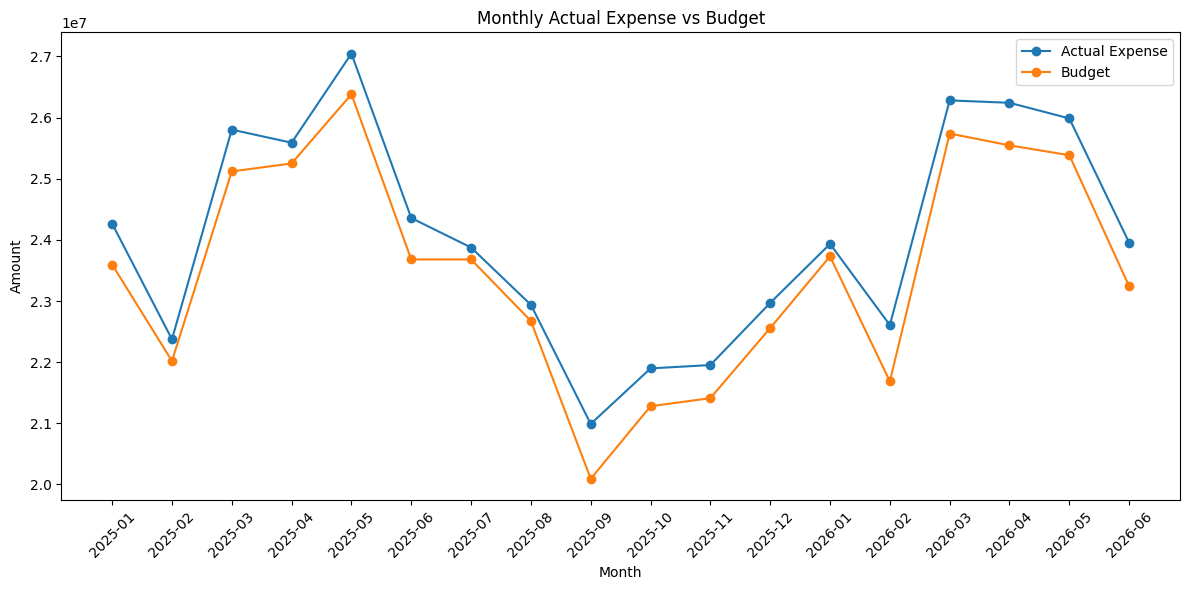

In [126]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_budget["month"],
    monthly_budget["actual_expense"],
    marker="o",
    label="Actual Expense"
)

plt.plot(
    monthly_budget["month"],
    monthly_budget["budget"],
    marker="o",
    label="Budget"
)

plt.xlabel("Month")
plt.ylabel("Amount")
plt.title("Monthly Actual Expense vs Budget")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

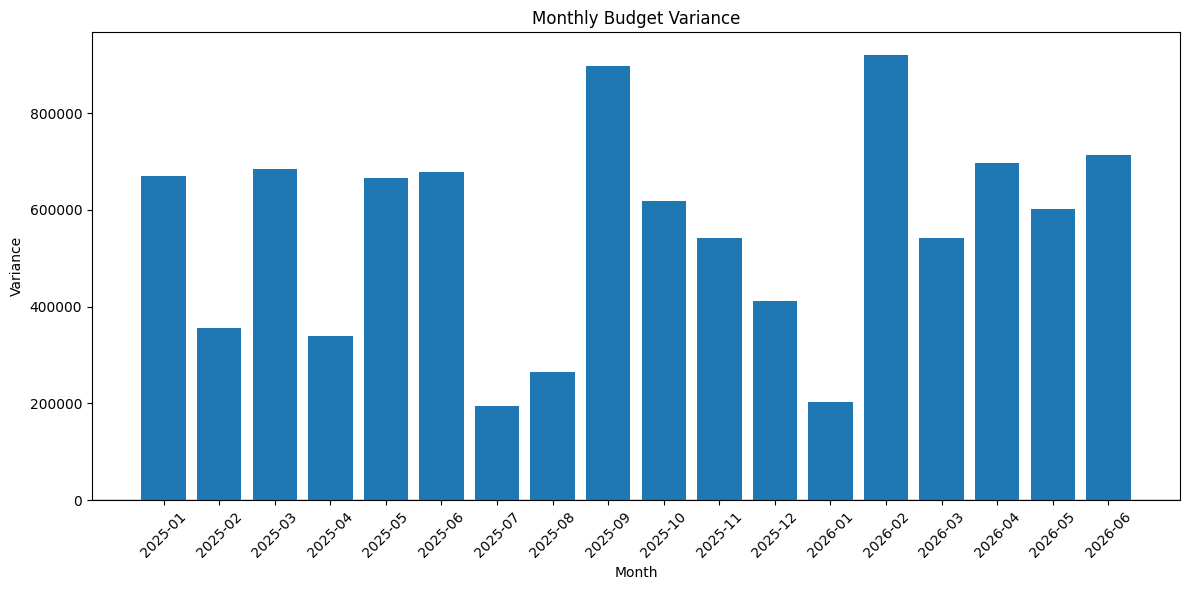

In [127]:
plt.figure(figsize=(12, 6))

plt.bar(
    monthly_budget["month"],
    monthly_budget["variance"]
)

plt.axhline(0, linewidth=1)

plt.xlabel("Month")
plt.ylabel("Variance")
plt.title("Monthly Budget Variance")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [128]:
worst_months = monthly_budget.sort_values(
    by="variance",
    ascending=False
)

display(
    worst_months[
        ["month", "actual_expense", "budget", "variance", "variance_percentage"]
    ].head(5)
)

,month,actual_expense,budget,variance,variance_percentage
13,2026-02,22606942.03,21686045.37,920896.66,4.246494
8,2025-09,20989586.47,20092132.22,897454.25,4.466695
17,2026-06,23954262.09,23240597.02,713665.07,3.070769
15,2026-04,26242169.89,25546283.33,695886.56,2.724023
2,2025-03,25803103.87,25119443.27,683660.60,2.721639


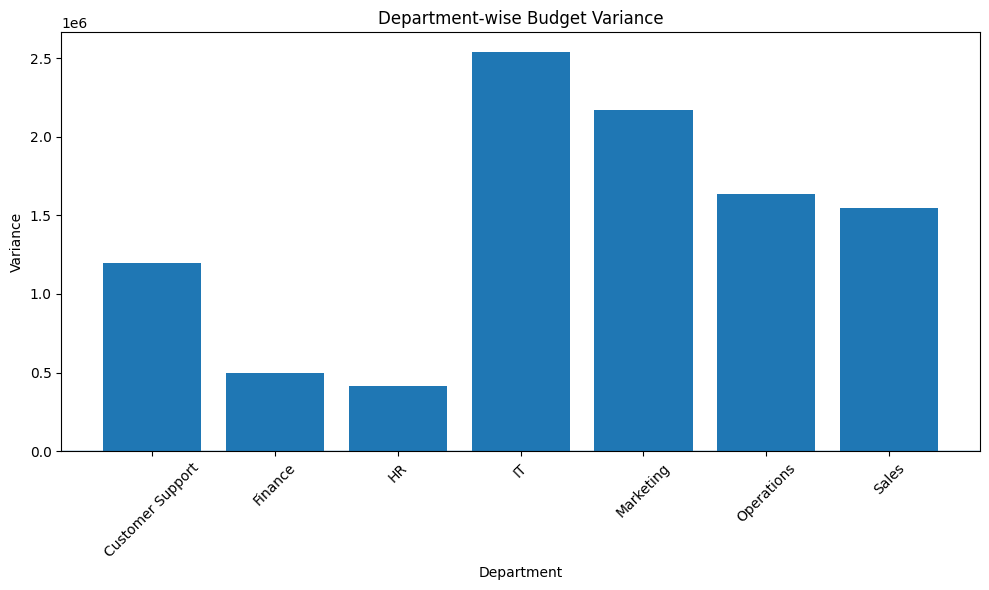

In [129]:
plt.figure(figsize=(10, 6))

plt.bar(
    department_budget["department"],
    department_budget["variance"]
)

plt.axhline(0, linewidth=1)

plt.xlabel("Department")
plt.ylabel("Variance")
plt.title("Department-wise Budget Variance")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [130]:
display(
    department_budget.sort_values(
        by="variance",
        ascending=False
    )
)

,department,actual_expense,budget,variance,variance_percentage
3,IT,8.202882e+07,7.949213e+07,2536688.84,3.191120
4,Marketing,8.272346e+07,8.055542e+07,2168040.14,2.691365
5,Operations,1.094409e+08,1.078074e+08,1633536.06,1.515236
6,Sales,6.571758e+07,6.417353e+07,1544043.31,2.406044
0,Customer Support,5.235406e+07,5.115626e+07,1197799.77,2.341453
1,Finance,2.321053e+07,2.271106e+07,499472.93,2.199250
2,HR,1.759032e+07,1.717453e+07,415790.13,2.420970


In [131]:
category_budget = budget_df.groupby("category").agg(
    actual_expense=("actual_expense", "sum"),
    budget=("budget", "sum")
).reset_index()

category_budget["variance"] = (
    category_budget["actual_expense"] - category_budget["budget"]
)

category_budget["variance_percentage"] = (
    category_budget["variance"] / category_budget["budget"]
) * 100

display(
    category_budget.sort_values(
        by="variance",
        ascending=False
    )
)

,category,actual_expense,budget,variance,variance_percentage
16,Software,73945464.71,72650056.64,1295408.07,1.783079
8,Cybersecurity,18945543.38,17963449.12,982094.26,5.467181
10,Hardware,23064056.31,22176839.37,887216.94,4.000646
0,Advertising,26862479.76,26036144.44,826335.32,3.173801
6,Commissions,20838729.02,20148192.50,690536.52,3.427288
21,Utilities,26067373.84,25437803.42,629570.42,2.474940
18,Support Tools,13584366.36,13028928.53,555437.83,4.263112
9,Events,21987623.07,21475827.87,511795.20,2.383122
17,Supplies,20327561.28,19836406.48,491154.80,2.476027
12,Maintenance,24629564.73,24141919.48,487645.25,2.019911


In [132]:
department_category = budget_df.groupby(
    ["department", "category"]
).agg(
    actual_expense=("actual_expense", "sum"),
    budget=("budget", "sum")
).reset_index()

department_category["variance"] = (
    department_category["actual_expense"]
    - department_category["budget"]
)

department_category["variance_percentage"] = (
    department_category["variance"]
    / department_category["budget"]
) * 100

display(
    department_category.sort_values(
        by="variance",
        ascending=False
    ).head(20)
)

,department,category,actual_expense,budget,variance,variance_percentage
13,IT,Cybersecurity,18945543.38,17963449.12,982094.26,5.467181
14,IT,Hardware,23064056.31,22176839.37,887216.94,4.000646
16,Marketing,Advertising,26862479.76,26036144.44,826335.32,3.173801
25,Sales,Commissions,20838729.02,20148192.50,690536.52,3.427288
23,Operations,Utilities,26067373.84,25437803.42,629570.42,2.474940
2,Customer Support,Support Tools,13584366.36,13028928.53,555437.83,4.263112
18,Marketing,Events,21987623.07,21475827.87,511795.20,2.383122
22,Operations,Supplies,20327561.28,19836406.48,491154.80,2.476027
21,Operations,Maintenance,24629564.73,24141919.48,487645.25,2.019911
17,Marketing,Content,15435060.03,14961474.41,473585.62,3.165367


In [133]:
display(
    category_budget.sort_values(
        by="variance_percentage",
        ascending=False
    ).head(10)
)

,category,actual_expense,budget,variance,variance_percentage
8,Cybersecurity,18945543.38,17963449.12,982094.26,5.467181
2,Bank Charges,4204550.96,4018341.32,186209.64,4.633993
18,Support Tools,13584366.36,13028928.53,555437.83,4.263112
10,Hardware,23064056.31,22176839.37,887216.94,4.000646
6,Commissions,20838729.02,20148192.50,690536.52,3.427288
3,Benefits,4657249.62,4512090.77,145158.85,3.217108
0,Advertising,26862479.76,26036144.44,826335.32,3.173801
7,Content,15435060.03,14961474.41,473585.62,3.165367
15,Recruitment,4340814.99,4210308.95,130506.04,3.099678
1,Audit,6474660.20,6310147.88,164512.32,2.607107


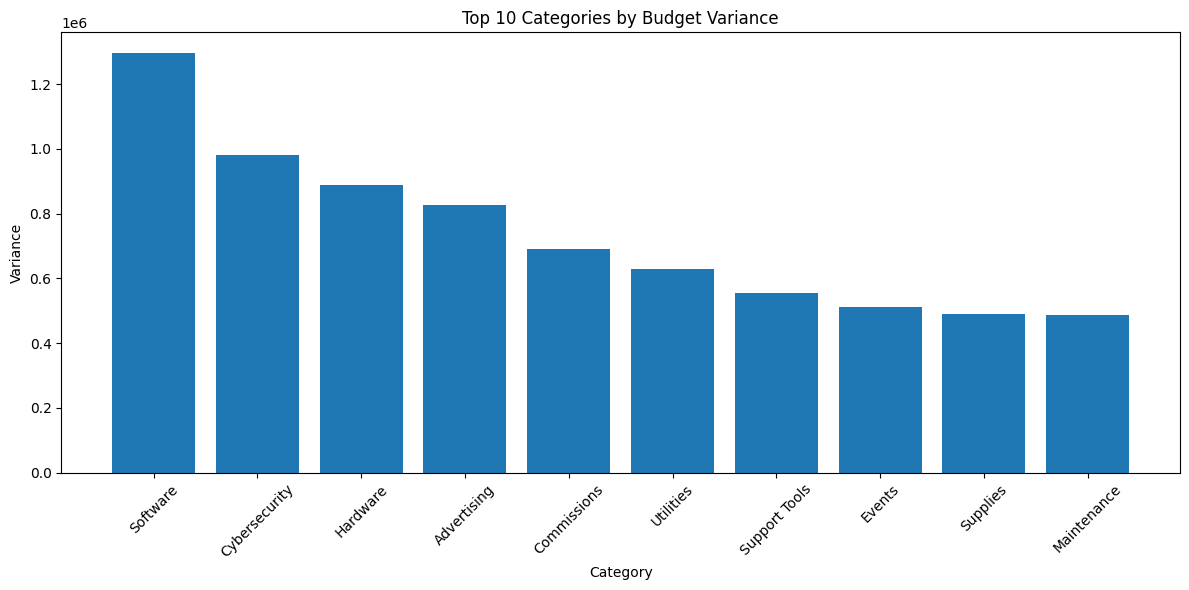

In [134]:
import matplotlib.pyplot as plt

top_categories = category_budget.sort_values(
    by="variance",
    ascending=False
).head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_categories["category"],
    top_categories["variance"]
)

plt.title("Top 10 Categories by Budget Variance")
plt.xlabel("Category")
plt.ylabel("Variance")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [135]:
department_category = budget_df.groupby(
    ["department", "category"]
).agg(
    actual_expense=("actual_expense", "sum"),
    budget=("budget", "sum")
).reset_index()

department_category["variance"] = (
    department_category["actual_expense"]
    - department_category["budget"]
)

department_category["variance_percentage"] = (
    department_category["variance"]
    / department_category["budget"]
) * 100

display(
    department_category.sort_values(
        by="variance",
        ascending=False
    ).head(20)
)

,department,category,actual_expense,budget,variance,variance_percentage
13,IT,Cybersecurity,18945543.38,17963449.12,982094.26,5.467181
14,IT,Hardware,23064056.31,22176839.37,887216.94,4.000646
16,Marketing,Advertising,26862479.76,26036144.44,826335.32,3.173801
25,Sales,Commissions,20838729.02,20148192.50,690536.52,3.427288
23,Operations,Utilities,26067373.84,25437803.42,629570.42,2.474940
2,Customer Support,Support Tools,13584366.36,13028928.53,555437.83,4.263112
18,Marketing,Events,21987623.07,21475827.87,511795.20,2.383122
22,Operations,Supplies,20327561.28,19836406.48,491154.80,2.476027
21,Operations,Maintenance,24629564.73,24141919.48,487645.25,2.019911
17,Marketing,Content,15435060.03,14961474.41,473585.62,3.165367


In [136]:
department_category = budget_df.groupby(
    ["department", "category"]
).agg(
    actual_expense=("actual_expense", "sum"),
    budget=("budget", "sum")
).reset_index()

department_category["variance"] = (
    department_category["actual_expense"]
    - department_category["budget"]
)

department_category["variance_percentage"] = (
    department_category["variance"]
    / department_category["budget"]
) * 100

display(
    department_category.sort_values(
        by="variance",
        ascending=False
    ).head(20)
)

,department,category,actual_expense,budget,variance,variance_percentage
13,IT,Cybersecurity,18945543.38,17963449.12,982094.26,5.467181
14,IT,Hardware,23064056.31,22176839.37,887216.94,4.000646
16,Marketing,Advertising,26862479.76,26036144.44,826335.32,3.173801
25,Sales,Commissions,20838729.02,20148192.50,690536.52,3.427288
23,Operations,Utilities,26067373.84,25437803.42,629570.42,2.474940
2,Customer Support,Support Tools,13584366.36,13028928.53,555437.83,4.263112
18,Marketing,Events,21987623.07,21475827.87,511795.20,2.383122
22,Operations,Supplies,20327561.28,19836406.48,491154.80,2.476027
21,Operations,Maintenance,24629564.73,24141919.48,487645.25,2.019911
17,Marketing,Content,15435060.03,14961474.41,473585.62,3.165367


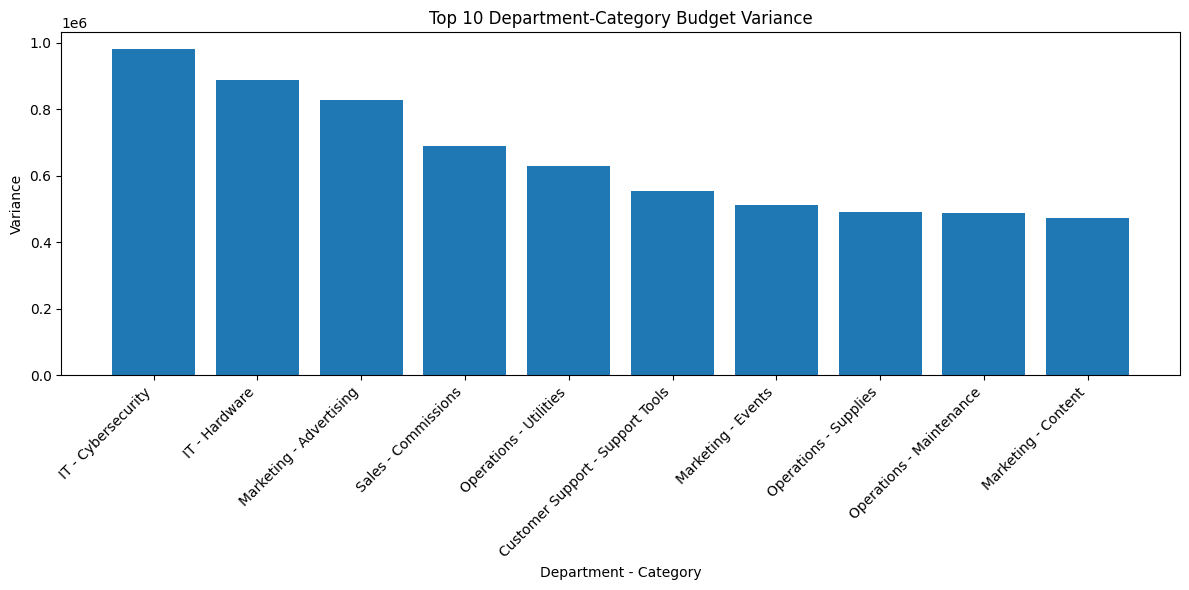

In [137]:
top_department_category = (
    department_category
    .sort_values(
        by="variance",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12, 6))

labels = (
    top_department_category["department"]
    + " - "
    + top_department_category["category"]
)

plt.bar(labels, top_department_category["variance"])

plt.title("Top 10 Department-Category Budget Variance")
plt.xlabel("Department - Category")
plt.ylabel("Variance")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [138]:
display(
    department_category.sort_values(
        by="variance_percentage",
        ascending=False
    ).head(10)
)

,department,category,actual_expense,budget,variance,variance_percentage
13,IT,Cybersecurity,18945543.38,17963449.12,982094.26,5.467181
5,Finance,Bank Charges,4204550.96,4018341.32,186209.64,4.633993
2,Customer Support,Support Tools,13584366.36,13028928.53,555437.83,4.263112
14,IT,Hardware,23064056.31,22176839.37,887216.94,4.000646
25,Sales,Commissions,20838729.02,20148192.50,690536.52,3.427288
8,HR,Benefits,4657249.62,4512090.77,145158.85,3.217108
16,Marketing,Advertising,26862479.76,26036144.44,826335.32,3.173801
17,Marketing,Content,15435060.03,14961474.41,473585.62,3.165367
9,HR,Recruitment,4340814.99,4210308.95,130506.04,3.099678
4,Finance,Audit,6474660.20,6310147.88,164512.32,2.607107


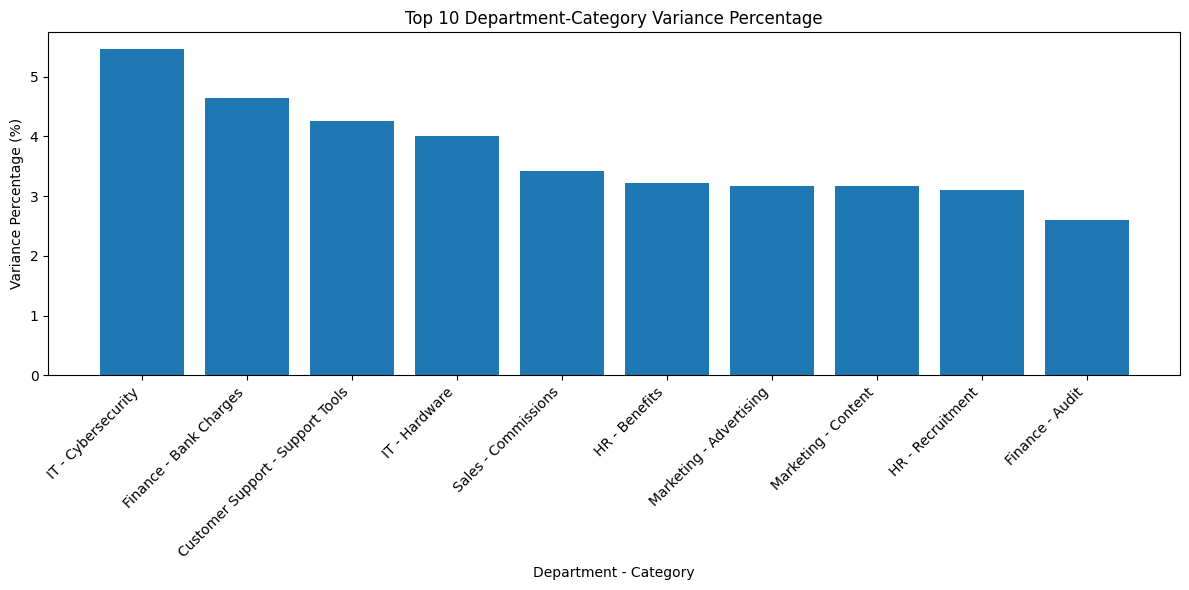

In [139]:
top_percentage = (
    department_category
    .sort_values(
        by="variance_percentage",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12, 6))

labels = (
    top_percentage["department"]
    + " - "
    + top_percentage["category"]
)

plt.bar(
    labels,
    top_percentage["variance_percentage"]
)

plt.title("Top 10 Department-Category Variance Percentage")
plt.xlabel("Department - Category")
plt.ylabel("Variance Percentage (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

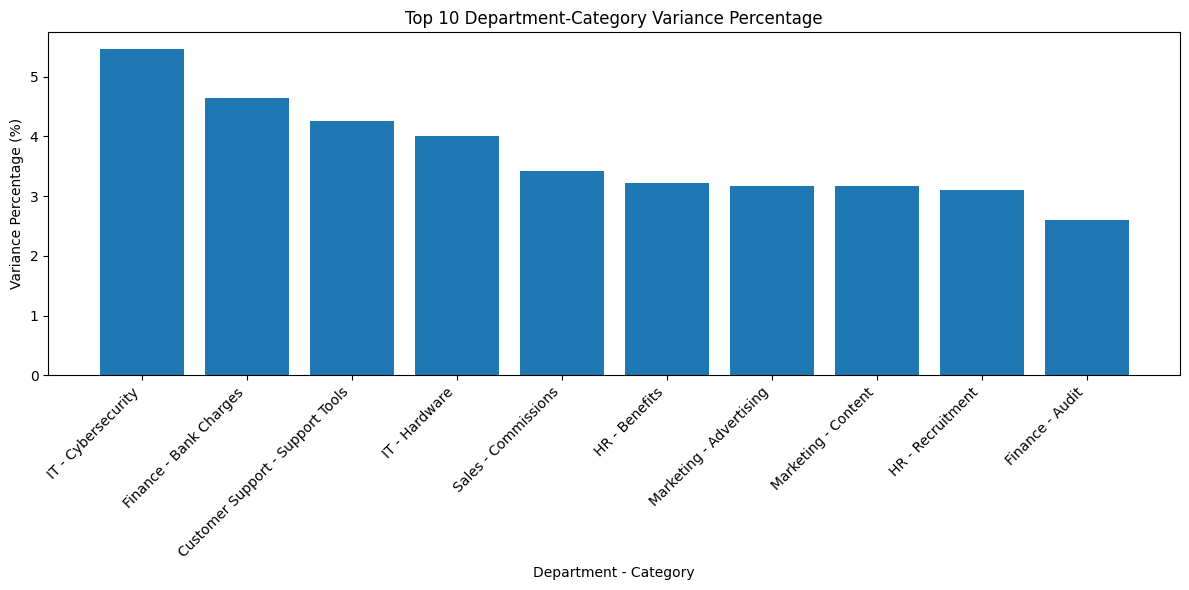

In [140]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    top_percentage["department"] + " - " + top_percentage["category"],
    top_percentage["variance_percentage"]
)

plt.title("Top 10 Department-Category Variance Percentage")
plt.xlabel("Department - Category")
plt.ylabel("Variance Percentage (%)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [141]:
top_variance = (
    department_category
    .sort_values(
        by="variance",
        ascending=False
    )
    .head(10)
)

display(top_variance)

,department,category,actual_expense,budget,variance,variance_percentage
13,IT,Cybersecurity,18945543.38,17963449.12,982094.26,5.467181
14,IT,Hardware,23064056.31,22176839.37,887216.94,4.000646
16,Marketing,Advertising,26862479.76,26036144.44,826335.32,3.173801
25,Sales,Commissions,20838729.02,20148192.50,690536.52,3.427288
23,Operations,Utilities,26067373.84,25437803.42,629570.42,2.474940
2,Customer Support,Support Tools,13584366.36,13028928.53,555437.83,4.263112
18,Marketing,Events,21987623.07,21475827.87,511795.20,2.383122
22,Operations,Supplies,20327561.28,19836406.48,491154.80,2.476027
21,Operations,Maintenance,24629564.73,24141919.48,487645.25,2.019911
17,Marketing,Content,15435060.03,14961474.41,473585.62,3.165367


In [142]:
department_summary = (
    budget_df.groupby("department")
    .agg(
        actual_expense=("actual_expense", "sum"),
        budget=("budget", "sum")
    )
    .reset_index()
)

department_summary["variance"] = (
    department_summary["actual_expense"]
    - department_summary["budget"]
)

department_summary["variance_percentage"] = (
    department_summary["variance"]
    / department_summary["budget"]
) * 100

display(
    department_summary.sort_values(
        by="variance",
        ascending=False
    )
)

,department,actual_expense,budget,variance,variance_percentage
3,IT,8.202882e+07,7.949213e+07,2536688.84,3.191120
4,Marketing,8.272346e+07,8.055542e+07,2168040.14,2.691365
5,Operations,1.094409e+08,1.078074e+08,1633536.06,1.515236
6,Sales,6.571758e+07,6.417353e+07,1544043.31,2.406044
0,Customer Support,5.235406e+07,5.115626e+07,1197799.77,2.341453
1,Finance,2.321053e+07,2.271106e+07,499472.93,2.199250
2,HR,1.759032e+07,1.717453e+07,415790.13,2.420970


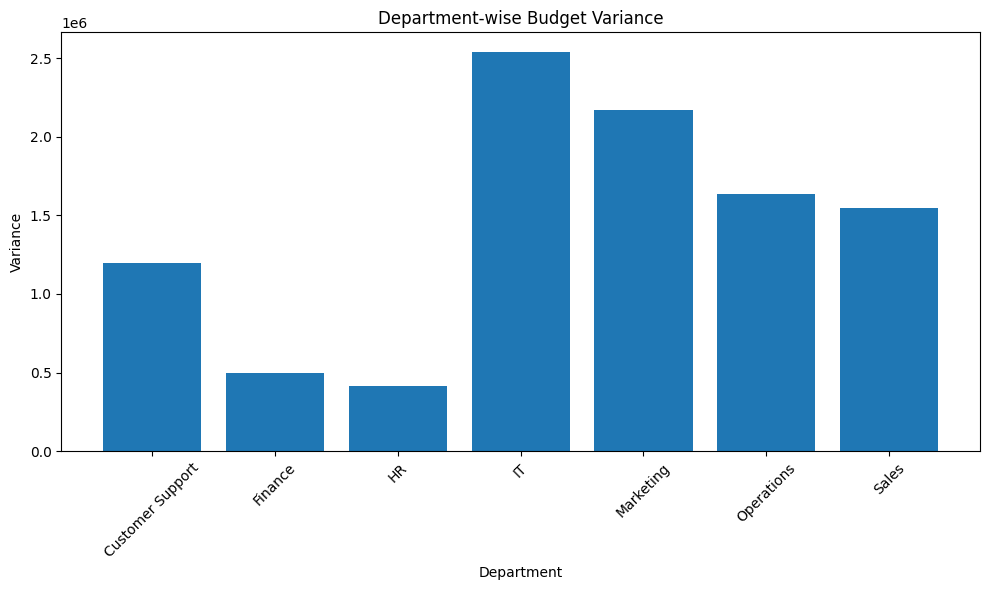

In [143]:
plt.figure(figsize=(10, 6))

plt.bar(
    department_summary["department"],
    department_summary["variance"]
)

plt.title("Department-wise Budget Variance")
plt.xlabel("Department")
plt.ylabel("Variance")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [144]:
top_department = (
    department_summary
    .sort_values(
        by="variance",
        ascending=False
    )
    .head(1)
)

display(top_department)

,department,actual_expense,budget,variance,variance_percentage
3,IT,82028815.67,79492126.83,2536688.84,3.19112


In [145]:
top_department_percentage = (
    department_summary
    .sort_values(
        by="variance_percentage",
        ascending=False
    )
    .head(1)
)

display(top_department_percentage)

,department,actual_expense,budget,variance,variance_percentage
3,IT,82028815.67,79492126.83,2536688.84,3.19112


In [146]:
top_category = (
    category_budget
    .sort_values(
        by="variance",
        ascending=False
    )
    .head(10)
)

display(top_category)

,category,actual_expense,budget,variance,variance_percentage
16,Software,73945464.71,72650056.64,1295408.07,1.783079
8,Cybersecurity,18945543.38,17963449.12,982094.26,5.467181
10,Hardware,23064056.31,22176839.37,887216.94,4.000646
0,Advertising,26862479.76,26036144.44,826335.32,3.173801
6,Commissions,20838729.02,20148192.50,690536.52,3.427288
21,Utilities,26067373.84,25437803.42,629570.42,2.474940
18,Support Tools,13584366.36,13028928.53,555437.83,4.263112
9,Events,21987623.07,21475827.87,511795.20,2.383122
17,Supplies,20327561.28,19836406.48,491154.80,2.476027
12,Maintenance,24629564.73,24141919.48,487645.25,2.019911


In [147]:
top_category_percentage = (
    category_budget
    .sort_values(
        by="variance_percentage",
        ascending=False
    )
    .head(10)
)

display(top_category_percentage)

,category,actual_expense,budget,variance,variance_percentage
8,Cybersecurity,18945543.38,17963449.12,982094.26,5.467181
2,Bank Charges,4204550.96,4018341.32,186209.64,4.633993
18,Support Tools,13584366.36,13028928.53,555437.83,4.263112
10,Hardware,23064056.31,22176839.37,887216.94,4.000646
6,Commissions,20838729.02,20148192.50,690536.52,3.427288
3,Benefits,4657249.62,4512090.77,145158.85,3.217108
0,Advertising,26862479.76,26036144.44,826335.32,3.173801
7,Content,15435060.03,14961474.41,473585.62,3.165367
15,Recruitment,4340814.99,4210308.95,130506.04,3.099678
1,Audit,6474660.20,6310147.88,164512.32,2.607107


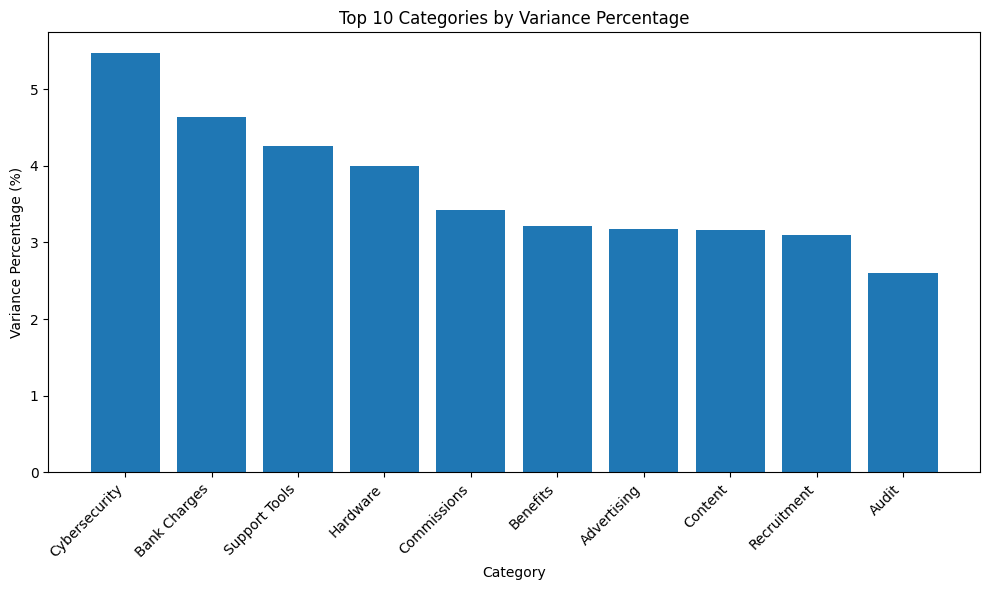

In [148]:
plt.figure(figsize=(10, 6))

plt.bar(
    top_category_percentage["category"],
    top_category_percentage["variance_percentage"]
)

plt.title("Top 10 Categories by Variance Percentage")
plt.xlabel("Category")
plt.ylabel("Variance Percentage (%)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [149]:
top_department_category_percentage = (
    department_category
    .sort_values(
        by="variance_percentage",
        ascending=False
    )
    .head(10)
)

display(top_department_category_percentage)

,department,category,actual_expense,budget,variance,variance_percentage
13,IT,Cybersecurity,18945543.38,17963449.12,982094.26,5.467181
5,Finance,Bank Charges,4204550.96,4018341.32,186209.64,4.633993
2,Customer Support,Support Tools,13584366.36,13028928.53,555437.83,4.263112
14,IT,Hardware,23064056.31,22176839.37,887216.94,4.000646
25,Sales,Commissions,20838729.02,20148192.50,690536.52,3.427288
8,HR,Benefits,4657249.62,4512090.77,145158.85,3.217108
16,Marketing,Advertising,26862479.76,26036144.44,826335.32,3.173801
17,Marketing,Content,15435060.03,14961474.41,473585.62,3.165367
9,HR,Recruitment,4340814.99,4210308.95,130506.04,3.099678
4,Finance,Audit,6474660.20,6310147.88,164512.32,2.607107


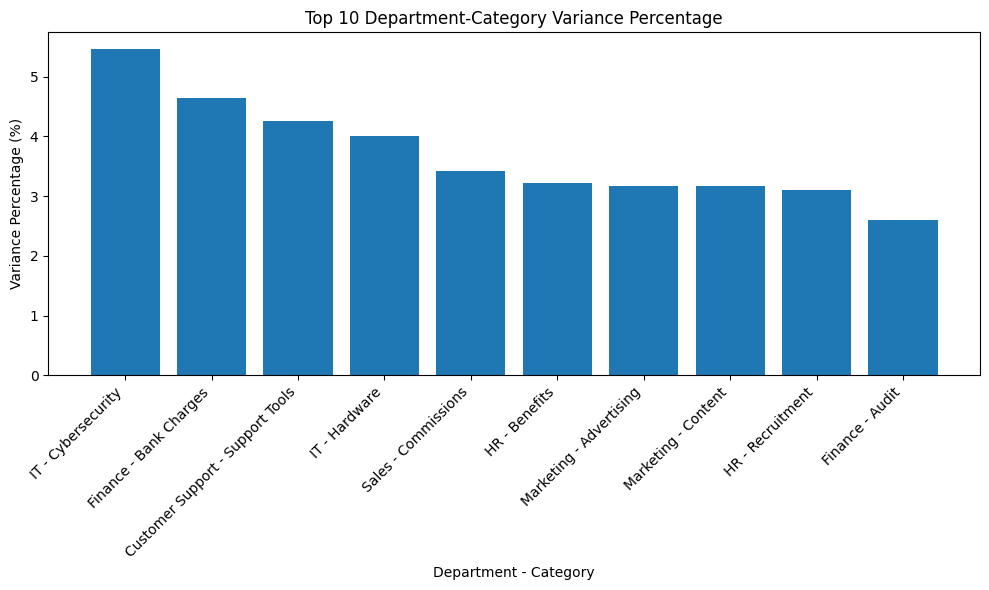

In [150]:
plt.figure(figsize=(10, 6))

plt.bar(
    top_department_category_percentage["department"] + " - " +
    top_department_category_percentage["category"],
    top_department_category_percentage["variance_percentage"]
)

plt.title("Top 10 Department-Category Variance Percentage")
plt.xlabel("Department - Category")
plt.ylabel("Variance Percentage (%)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

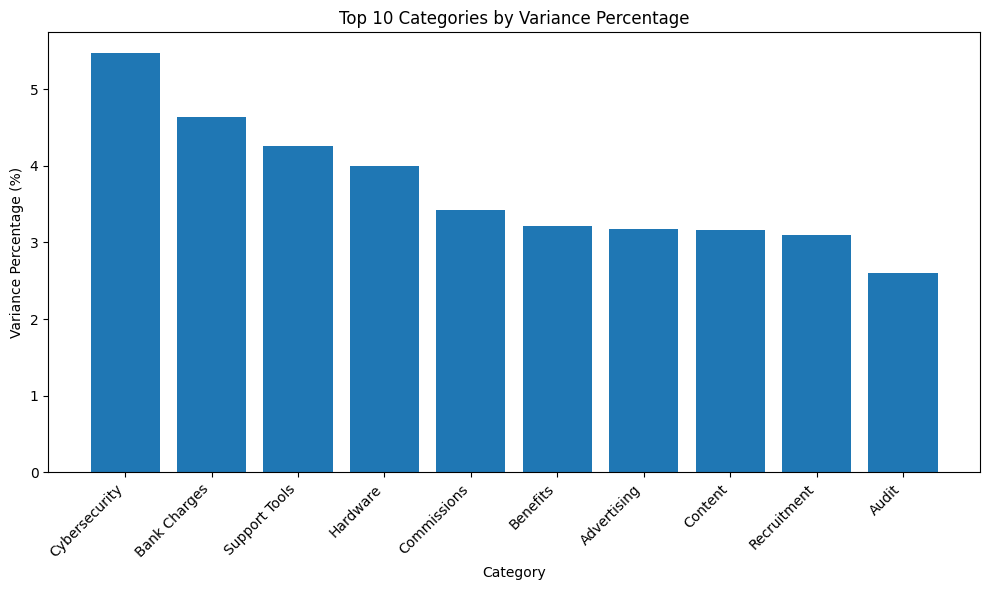

In [151]:
plt.figure(figsize=(10, 6))

plt.bar(
    top_category_percentage["category"],
    top_category_percentage["variance_percentage"]
)

plt.title("Top 10 Categories by Variance Percentage")
plt.xlabel("Category")
plt.ylabel("Variance Percentage (%)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [152]:
top_category = (
    category_budget
    .sort_values(
        by="variance",
        ascending=False
    )
    .head(10)
)

display(top_category)

,category,actual_expense,budget,variance,variance_percentage
16,Software,73945464.71,72650056.64,1295408.07,1.783079
8,Cybersecurity,18945543.38,17963449.12,982094.26,5.467181
10,Hardware,23064056.31,22176839.37,887216.94,4.000646
0,Advertising,26862479.76,26036144.44,826335.32,3.173801
6,Commissions,20838729.02,20148192.50,690536.52,3.427288
21,Utilities,26067373.84,25437803.42,629570.42,2.474940
18,Support Tools,13584366.36,13028928.53,555437.83,4.263112
9,Events,21987623.07,21475827.87,511795.20,2.383122
17,Supplies,20327561.28,19836406.48,491154.80,2.476027
12,Maintenance,24629564.73,24141919.48,487645.25,2.019911


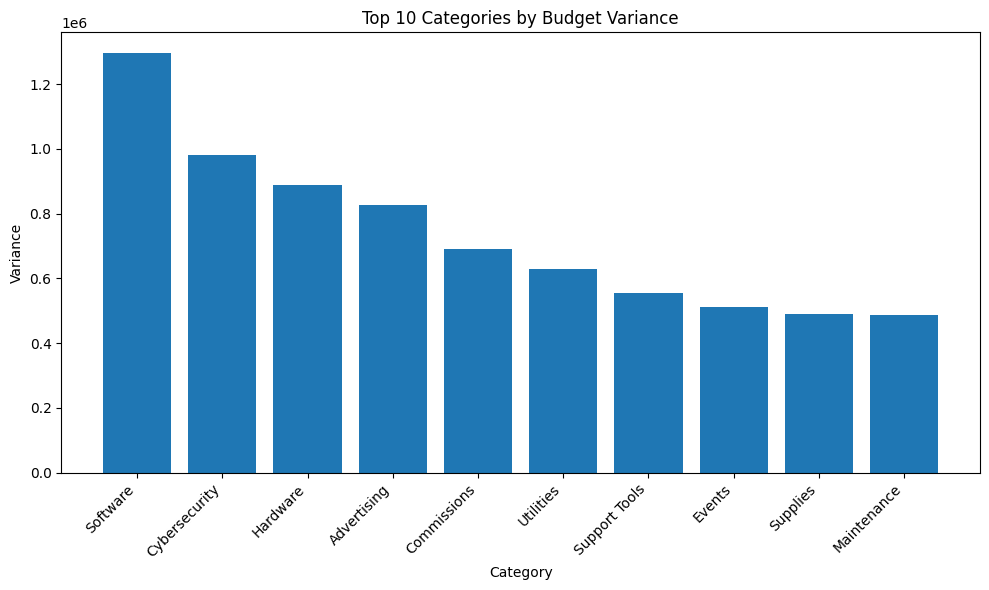

In [153]:
plt.figure(figsize=(10, 6))

plt.bar(
    top_category["category"],
    top_category["variance"]
)

plt.title("Top 10 Categories by Budget Variance")
plt.xlabel("Category")
plt.ylabel("Variance")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [154]:
top_department_percentage = (
    department_summary
    .sort_values(
        by="variance_percentage",
        ascending=False
    )
    .head(1)
)

display(top_department_percentage)

,department,actual_expense,budget,variance,variance_percentage
3,IT,82028815.67,79492126.83,2536688.84,3.19112


In [155]:
top_department_percentage = (
    department_summary
    .sort_values(
        by="variance_percentage",
        ascending=False
    )
    .head(1)
)

display(top_department_percentage)

,department,actual_expense,budget,variance,variance_percentage
3,IT,82028815.67,79492126.83,2536688.84,3.19112


In [156]:
lowest_department_percentage = (
    department_summary
    .sort_values(
        by="variance_percentage",
        ascending=True
    )
    .head(1)
)

display(lowest_department_percentage)

,department,actual_expense,budget,variance,variance_percentage
5,Operations,1.094409e+08,1.078074e+08,1633536.06,1.515236


In [157]:
top_department_variance = (
    department_summary
    .sort_values(
        by="variance",
        ascending=False
    )
    .head(10)
)

display(top_department_variance)

,department,actual_expense,budget,variance,variance_percentage
3,IT,8.202882e+07,7.949213e+07,2536688.84,3.191120
4,Marketing,8.272346e+07,8.055542e+07,2168040.14,2.691365
5,Operations,1.094409e+08,1.078074e+08,1633536.06,1.515236
6,Sales,6.571758e+07,6.417353e+07,1544043.31,2.406044
0,Customer Support,5.235406e+07,5.115626e+07,1197799.77,2.341453
1,Finance,2.321053e+07,2.271106e+07,499472.93,2.199250
2,HR,1.759032e+07,1.717453e+07,415790.13,2.420970


In [158]:
top_departments_percentage = (
    department_summary
    .sort_values(
        by="variance_percentage",
        ascending=False
    )
    .head(10)
)

display(top_departments_percentage)

,department,actual_expense,budget,variance,variance_percentage
3,IT,8.202882e+07,7.949213e+07,2536688.84,3.191120
4,Marketing,8.272346e+07,8.055542e+07,2168040.14,2.691365
2,HR,1.759032e+07,1.717453e+07,415790.13,2.420970
6,Sales,6.571758e+07,6.417353e+07,1544043.31,2.406044
0,Customer Support,5.235406e+07,5.115626e+07,1197799.77,2.341453
1,Finance,2.321053e+07,2.271106e+07,499472.93,2.199250
5,Operations,1.094409e+08,1.078074e+08,1633536.06,1.515236


In [159]:
lowest_department_variance = (
    department_summary
    .sort_values(
        by="variance",
        ascending=True
    )
    .head(1)
)

display(lowest_department_variance)

,department,actual_expense,budget,variance,variance_percentage
2,HR,17590316.37,17174526.24,415790.13,2.42097


In [160]:
lowest_category_percentage = (
    category_budget
    .sort_values(
        by="variance_percentage",
        ascending=True
    )
    .head(1)
)

display(lowest_category_percentage)

,category,actual_expense,budget,variance,variance_percentage
11,Logistics,38416393.87,38391228.28,25165.59,0.06555


In [161]:
highest_category_percentage = (
    category_budget
    .sort_values(
        by="variance_percentage",
        ascending=False
    )
    .head(1)
)

display(highest_category_percentage)

,category,actual_expense,budget,variance,variance_percentage
8,Cybersecurity,18945543.38,17963449.12,982094.26,5.467181


In [162]:
highest_category_percentage = (
    category_budget
    .sort_values(
        by="variance_percentage",
        ascending=False
    )
    .head(1)
)

display(highest_category_percentage)

,category,actual_expense,budget,variance,variance_percentage
8,Cybersecurity,18945543.38,17963449.12,982094.26,5.467181


In [163]:
lowest_category_variance = (
    category_budget
    .sort_values(
        by="variance",
        ascending=True
    )
    .head(1)
)

display(lowest_category_variance)

,category,actual_expense,budget,variance,variance_percentage
11,Logistics,38416393.87,38391228.28,25165.59,0.06555


In [164]:
lowest_department_category_percentage = (
    department_category
    .sort_values(
        by="variance_percentage",
        ascending=True
    )
    .head(1)
)

display(lowest_department_category_percentage)

,department,category,actual_expense,budget,variance,variance_percentage
20,Operations,Logistics,38416393.87,38391228.28,25165.59,0.06555


In [165]:
#FINAL DATA VALIDATION SUMMARY
validation_summary = {
    "total_departments": department_summary.shape[0],
    "total_categories": category_budget.shape[0],
    "highest_department_variance_pct": department_summary["variance_percentage"].max(),
    "lowest_department_variance_pct": department_summary["variance_percentage"].min(),
    "highest_category_variance_pct": category_budget["variance_percentage"].max(),
    "lowest_category_variance_pct": category_budget["variance_percentage"].min()
}

display(validation_summary)

{'total_departments': 7,
 'total_categories': 22,
 'highest_department_variance_pct': np.float64(3.191119600340933),
 'lowest_department_variance_pct': np.float64(1.5152361540589887),
 'highest_category_variance_pct': np.float64(5.467180904064586),
 'lowest_category_variance_pct': np.float64(0.0655503643083652)}

In [167]:
[name for name, value in globals().items()
 if hasattr(value, "columns") and hasattr(value, "shape")]

['df',
 'budget_df',
 'over_budget',
 'monthly_budget',
 'department_budget',
 'category_budget',
 'top_overruns',
 'worst_months',
 'department_category',
 'top_categories',
 'top_department_category',
 'top_percentage',
 'top_variance',
 'department_summary',
 'top_department',
 'top_department_percentage',
 'top_category',
 'top_category_percentage',
 'top_department_category_percentage',
 'lowest_department_percentage',
 'top_department_variance',
 'top_departments_percentage',
 'lowest_department_variance',
 'lowest_category_percentage',
 'highest_category_percentage',
 'lowest_category_variance',
 'lowest_department_category_percentage']

In [168]:
# Final validation checks

print("Departments:", department_summary.shape[0])
print("Categories:", category_budget.shape[0])
print("Department-Category combinations:", department_category.shape[0])

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Departments: 7
Categories: 22
Department-Category combinations: 28

Missing values:


transaction_id      0
date                0
department          0
category            0
vendor              0
region              0
transaction_type    0
amount              0
payment_method      0
description         0
dtype: int64


Duplicate rows: 0


In [169]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [170]:
print("Duplicate transaction IDs:", df["transaction_id"].duplicated().sum())

Duplicate transaction IDs: 0


In [171]:
print("Zero amounts:", (df["amount"] == 0).sum())
print("Negative amounts:", (df["amount"] < 0).sum())

Zero amounts: 0
Negative amounts: 0


In [172]:
print("Invalid dates:", df["date"].isna().sum())
print("Minimum date:", df["date"].min())
print("Maximum date:", df["date"].max())

Invalid dates: 0
Minimum date: 2025-01-01 00:00:00
Maximum date: 2026-06-29 00:00:00


In [173]:
df.dtypes

transaction_id              object
date                datetime64[ns]
department                  object
category                    object
vendor                      object
region                      object
transaction_type            object
amount                     float64
payment_method              object
description                 object
dtype: object

In [174]:
print("Departments:", df["department"].nunique())
print("Categories:", df["category"].nunique())
print("Transaction types:", df["transaction_type"].nunique())
print("Payment methods:", df["payment_method"].nunique())
print("Regions:", df["region"].nunique())

Departments: 7
Categories: 26
Transaction types: 2
Payment methods: 5
Regions: 4


In [175]:
sorted(df["category"].unique())

['Advertising',
 'Audit',
 'Bank Charges',
 'Benefits',
 'Client Entertainment',
 'Cloud Services',
 'Commissions',
 'Content',
 'Cybersecurity',
 'Events',
 'Hardware',
 'Logistics',
 'Maintenance',
 'Outsourcing',
 'Product Sales',
 'Professional Services',
 'Recruitment',
 'Service Revenue',
 'Software',
 'Subscription',
 'Supplies',
 'Support Tools',
 'Training',
 'Transaction Fees',
 'Travel',
 'Utilities']

In [176]:
transaction_categories = set(df["category"].unique())
budget_categories = set(category_budget["category"].unique())

missing_budget_categories = sorted(transaction_categories - budget_categories)

print("Categories in transactions:", len(transaction_categories))
print("Categories in budget:", len(budget_categories))
print("Categories without budget:", len(missing_budget_categories))
print(missing_budget_categories)

Categories in transactions: 26
Categories in budget: 22
Categories without budget: 4
['Product Sales', 'Service Revenue', 'Subscription', 'Transaction Fees']


In [177]:
missing_budget_summary = (
    df[df["category"].isin(missing_budget_categories)]
    .groupby("category")
    .agg(
        transaction_count=("transaction_id", "count"),
        total_amount=("amount", "sum")
    )
    .reset_index()
    .sort_values("total_amount", ascending=False)
)

display(missing_budget_summary)

,category,transaction_count,total_amount
0,Product Sales,5807,1.300131e+08
3,Transaction Fees,5628,1.278683e+08
2,Subscription,5723,1.275539e+08
1,Service Revenue,5652,1.264267e+08


In [180]:
data_dictionary_df = pd.read_csv("../dataset/data_dictionary.csv")

print(data_dictionary_df.columns)
display(data_dictionary_df.head())

Index(['column', 'meaning', 'example'], dtype='object')


,column,meaning,example
0,transaction_id,Unique transaction identifier,TXN100001
1,date,Transaction date,2026-04-15
2,department,Business department responsible for transaction,Marketing
3,category,Financial category,Advertising
4,vendor,Vendor or customer group,AdSphere


In [181]:
ground_truth_df = pd.read_csv("../dataset/ground_truth.csv")

print("Ground truth columns:")
print(ground_truth_df.columns)

display(ground_truth_df.head())

Ground truth columns:
Index(['scenario_id', 'period', 'metric', 'expected_root_cause',
       'expected_vendor', 'description'],
      dtype='object')


,scenario_id,period,metric,expected_root_cause,expected_vendor,description
0,SCN001,2026-04,Operating Expense,Marketing > Advertising,AdSphere / MarketBoost / SearchPro,Marketing Advertising spending was intentional...
1,SCN002,2026-05,Revenue,South Region > Revenue,Customer segment,South-region revenue transaction values were i...
2,SCN003,2026-03,Operating Expense,IT > Software > CloudSuite,CloudSuite,CloudSuite software spending was intentionally...
3,SCN004,2026-02,Operating Expense,Operations > Logistics,FastFreight / MoveRight / ShipNow,Operations logistics spending was intentionall...
4,SCN005,2026-06,Operating Expense,HR > Recruitment,TalentBridge / HireFast,HR recruitment spending was intentionally incr...


In [182]:
transaction_columns = set(df.columns)
dictionary_columns = set(data_dictionary_df["column"])

print("Columns in transactions:", sorted(transaction_columns))
print("Columns in data dictionary:", sorted(dictionary_columns))

print("\nColumns missing from data dictionary:")
print(sorted(transaction_columns - dictionary_columns))

print("\nExtra columns in data dictionary:")
print(sorted(dictionary_columns - transaction_columns))

Columns in transactions: ['amount', 'category', 'date', 'department', 'description', 'payment_method', 'region', 'transaction_id', 'transaction_type', 'vendor']
Columns in data dictionary: ['amount', 'budget', 'category', 'date', 'department', 'description', 'payment_method', 'region', 'transaction_id', 'transaction_type', 'vendor']

Columns missing from data dictionary:
[]

Extra columns in data dictionary:
['budget']


In [183]:
print("Blank categories:", df["category"].isna().sum())
print(
    "Whitespace/empty categories:",
    (df["category"].astype(str).str.strip() == "").sum()
)

print("\nCategory values with leading/trailing spaces:")
print(
    df.loc[
        df["category"].astype(str) != df["category"].astype(str).str.strip(),
        "category"
    ].unique()
)

Blank categories: 0
Whitespace/empty categories: 0

Category values with leading/trailing spaces:
[]


In [184]:
categorical_columns = [
    "department",
    "vendor",
    "region",
    "transaction_type",
    "payment_method"
]

for col in categorical_columns:
    print(f"\n--- {col} ---")
    print("Missing:", df[col].isna().sum())
    print("Empty/whitespace:", (df[col].astype(str).str.strip() == "").sum())
    print(
        "Leading/trailing spaces:",
        (df[col].astype(str) != df[col].astype(str).str.strip()).sum()
    )


--- department ---
Missing: 0
Empty/whitespace: 0
Leading/trailing spaces: 0

--- vendor ---
Missing: 0
Empty/whitespace: 0
Leading/trailing spaces: 0

--- region ---
Missing: 0
Empty/whitespace: 0
Leading/trailing spaces: 0

--- transaction_type ---
Missing: 0
Empty/whitespace: 0
Leading/trailing spaces: 0

--- payment_method ---
Missing: 0
Empty/whitespace: 0
Leading/trailing spaces: 0


In [185]:
print("Categories in data dictionary:")

display(
    data_dictionary_df[
        data_dictionary_df["column"].eq("category")
    ]
)

Categories in data dictionary:


,column,meaning,example
3,category,Financial category,Advertising


In [186]:
transaction_departments = set(df["department"].unique())
budget_departments = set(department_summary["department"].unique())

missing_budget_departments = sorted(
    transaction_departments - budget_departments
)

print("Departments in transactions:", len(transaction_departments))
print("Departments in budget:", len(budget_departments))
print("Departments without budget:", len(missing_budget_departments))
print(missing_budget_departments)

Departments in transactions: 7
Departments in budget: 7
Departments without budget: 0
[]


In [187]:
transaction_combinations = set(
    zip(df["department"], df["category"])
)

budget_combinations = set(
    zip(
        department_category["department"],
        department_category["category"]
    )
)

missing_budget_combinations = sorted(
    transaction_combinations - budget_combinations
)

print("Transaction combinations:", len(transaction_combinations))
print("Budget combinations:", len(budget_combinations))
print("Combinations without budget:", len(missing_budget_combinations))
print(missing_budget_combinations)

Transaction combinations: 56
Budget combinations: 28
Combinations without budget: 28
[('Customer Support', 'Product Sales'), ('Customer Support', 'Service Revenue'), ('Customer Support', 'Subscription'), ('Customer Support', 'Transaction Fees'), ('Finance', 'Product Sales'), ('Finance', 'Service Revenue'), ('Finance', 'Subscription'), ('Finance', 'Transaction Fees'), ('HR', 'Product Sales'), ('HR', 'Service Revenue'), ('HR', 'Subscription'), ('HR', 'Transaction Fees'), ('IT', 'Product Sales'), ('IT', 'Service Revenue'), ('IT', 'Subscription'), ('IT', 'Transaction Fees'), ('Marketing', 'Product Sales'), ('Marketing', 'Service Revenue'), ('Marketing', 'Subscription'), ('Marketing', 'Transaction Fees'), ('Operations', 'Product Sales'), ('Operations', 'Service Revenue'), ('Operations', 'Subscription'), ('Operations', 'Transaction Fees'), ('Sales', 'Product Sales'), ('Sales', 'Service Revenue'), ('Sales', 'Subscription'), ('Sales', 'Transaction Fees')]


In [188]:
missing_categories = sorted(
    set(category for department, category in missing_budget_combinations)
)

print("Missing-budget categories:")
print(missing_categories)

print("\nCount by category:")
print(
    df[
        df.apply(
            lambda row: (row["department"], row["category"])
            in missing_budget_combinations,
            axis=1
        )
    ]["category"].value_counts()
)

Missing-budget categories:
['Product Sales', 'Service Revenue', 'Subscription', 'Transaction Fees']

Count by category:
category
Product Sales       5807
Subscription        5723
Service Revenue     5652
Transaction Fees    5628
Name: count, dtype: int64


In [189]:
print("Budget missing values:")
display(department_category.isna().sum())

print("\nBudget duplicate rows:")
print(department_category.duplicated().sum())

print("\nBudget duplicate department-category pairs:")
print(
    department_category[
        ["department", "category"]
    ].duplicated().sum()
)

print("\nNegative budget amounts:")
print(
    (department_category["budget"] < 0).sum()
)

print("\nZero budget amounts:")
print(
    (department_category["budget"] == 0).sum()
)

Budget missing values:


department             0
category               0
actual_expense         0
budget                 0
variance               0
variance_percentage    0
dtype: int64


Budget duplicate rows:
0

Budget duplicate department-category pairs:
0

Negative budget amounts:
0

Zero budget amounts:
0


In [190]:
# Validate variance calculation
expected_variance = (
    department_category["actual_expense"]
    - department_category["budget"]
)

print(
    "Incorrect variance values:",
    (
        (department_category["variance"] - expected_variance).abs() > 0.01
    ).sum()
)

# Validate variance percentage calculation
expected_variance_percentage = (
    department_category["variance"]
    / department_category["budget"]
    * 100
)

print(
    "Incorrect variance percentage values:",
    (
        (
            department_category["variance_percentage"]
            - expected_variance_percentage
        ).abs() > 0.01
    ).sum()
)

Incorrect variance values: 0
Incorrect variance percentage values: 0


In [191]:
print("Ground truth missing values:")
print(ground_truth_df.isna().sum())

print("\nGround truth duplicate rows:")
print(ground_truth_df.duplicated().sum())

print("\nDuplicate scenario IDs:")
print(ground_truth_df["scenario_id"].duplicated().sum())

print("\nUnique scenario IDs:")
print(ground_truth_df["scenario_id"].nunique())

print("\nPeriods:")
print(sorted(ground_truth_df["period"].unique()))

Ground truth missing values:
scenario_id            0
period                 0
metric                 0
expected_root_cause    0
expected_vendor        0
description            0
dtype: int64

Ground truth duplicate rows:
0

Duplicate scenario IDs:
0

Unique scenario IDs:
5

Periods:
['2026-02', '2026-03', '2026-04', '2026-05', '2026-06']


In [192]:
print("Metrics:")
print(ground_truth_df["metric"].value_counts())

print("\nScenario IDs:")
print(sorted(ground_truth_df["scenario_id"].unique()))

print("\nExpected root causes:")
print(ground_truth_df["expected_root_cause"].tolist())

print("\nExpected vendors:")
print(ground_truth_df["expected_vendor"].tolist())

Metrics:
metric
Operating Expense    4
Revenue              1
Name: count, dtype: int64

Scenario IDs:
['SCN001', 'SCN002', 'SCN003', 'SCN004', 'SCN005']

Expected root causes:
['Marketing > Advertising', 'South Region > Revenue', 'IT > Software > CloudSuite', 'Operations > Logistics', 'HR > Recruitment']

Expected vendors:
['AdSphere / MarketBoost / SearchPro', 'Customer segment', 'CloudSuite', 'FastFreight / MoveRight / ShipNow', 'TalentBridge / HireFast']


In [193]:
print("Ground truth period format:")
print(ground_truth_df["period"].str.match(r"^\d{4}-\d{2}$").all())

print("\nBlank expected root causes:")
print((ground_truth_df["expected_root_cause"].astype(str).str.strip() == "").sum())

print("\nBlank expected vendors:")
print((ground_truth_df["expected_vendor"].astype(str).str.strip() == "").sum())

print("\nBlank descriptions:")
print((ground_truth_df["description"].astype(str).str.strip() == "").sum())

print("\nValid metrics:")
print(set(ground_truth_df["metric"].unique()) <= {"Operating Expense", "Revenue"})

Ground truth period format:
True

Blank expected root causes:
0

Blank expected vendors:
0

Blank descriptions:
0

Valid metrics:
True


In [194]:
print("Ground truth periods within transaction date range:")

transaction_periods = set(df["date"].dt.to_period("M").astype(str))
ground_truth_periods = set(ground_truth_df["period"])

print(ground_truth_periods.issubset(transaction_periods))

print("\nGround truth periods missing from transactions:")
print(sorted(ground_truth_periods - transaction_periods))

print("\nGround truth scenario count:")
print(len(ground_truth_df))

print("\nGround truth validation status:")
print(
    ground_truth_df.isna().sum().sum() == 0
    and ground_truth_df["scenario_id"].is_unique
    and ground_truth_df["period"].str.match(r"^\d{4}-\d{2}$").all()
)

Ground truth periods within transaction date range:
True

Ground truth periods missing from transactions:
[]

Ground truth scenario count:
5

Ground truth validation status:
True


In [ ]:
## Data Validation Summary

'''The transaction, budget, data dictionary, and ground-truth datasets were validated for structural integrity and data quality.

### Validation Results

- Transaction duplicate `transaction_id`s: 0
- Zero transaction amounts: 0
- Negative transaction amounts: 0
- Invalid transaction dates: 0
- Transaction date range: 2025-01-01 to 2026-06-29
- Missing values in categorical columns: 0
- Blank/whitespace categorical values: 0
- Leading/trailing whitespace issues: 0
- Transaction departments without budgets: 0
- Transaction categories without budgets: 4
- Missing department-category budget combinations: 28
- Budget missing values: 0
- Budget duplicate rows: 0
- Budget duplicate department-category pairs: 0
- Negative budget amounts: 0
- Zero budget amounts: 0
- Incorrect budget variance values: 0
- Incorrect variance percentage values: 0
- Ground-truth missing values: 0
- Ground-truth duplicate rows: 0
- Duplicate ground-truth scenario IDs: 0
- Ground-truth scenarios: 5
- Ground-truth periods within transaction date range: Yes
 
- Ground-truth validation status: Passed

### Conclusion
The datasets passed the core data-quality and structural validation checks. No corrective cleaning is required at this stage.

The four transaction categories without budget definitions and the 28 missing department-category budget combinations are documented as business-coverage gaps rather than treated as data-quality errors.'''

SyntaxError: leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers (1899410464.py, line 11)